In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/cleaned/ipo_cleaned.csv')
print("Shape:", df.shape)
print("QIB nulls:", df['QIB'].isnull().sum())
print("Listing Gain nulls:", df['Listing Gain'].isnull().sum())

Shape: (549, 19)
QIB nulls: 0
Listing Gain nulls: 0


In [3]:
qib_corr = df['QIB'].corr(df['Listing Gain'])
rii_corr = df['RII'].corr(df['Listing Gain'])
print(f"QIB vs Listing Gain correlation: {qib_corr:.4f}")
print(f"RII vs Listing Gain correlation: {rii_corr:.4f}")
print(f"\nWhich is stronger predictor: {'QIB' if abs(qib_corr) > abs(rii_corr) else 'RII'}")

QIB vs Listing Gain correlation: 0.6218
RII vs Listing Gain correlation: 0.5148

Which is stronger predictor: QIB


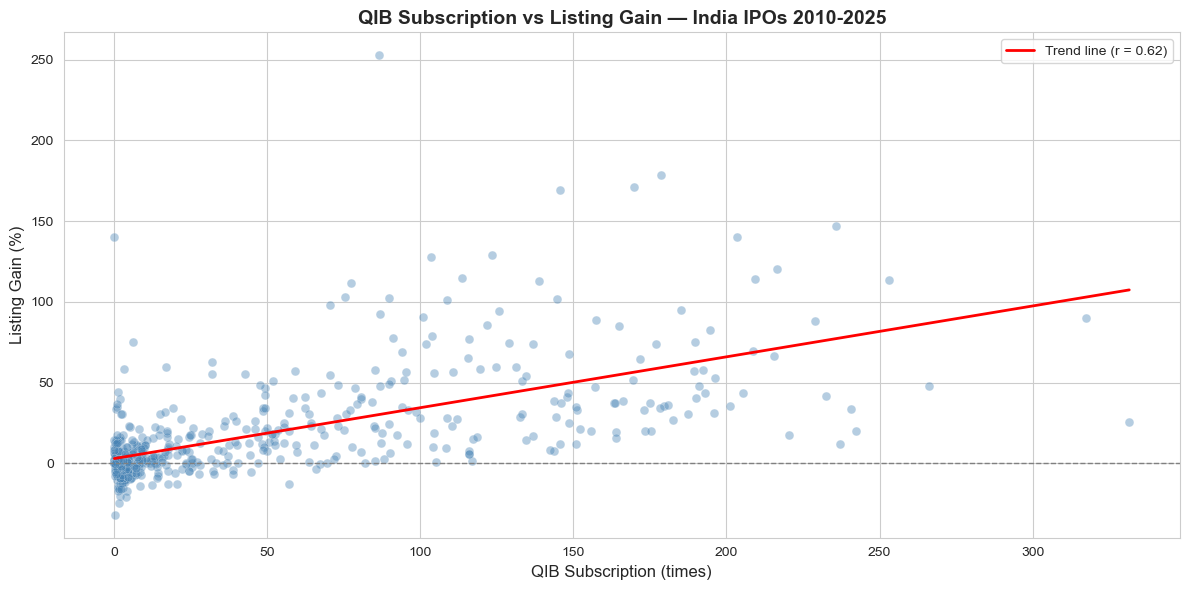

Chart saved.


In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

fig, ax = plt.subplots()
ax.scatter(
    df['QIB'],
    df['Listing Gain'],
    alpha=0.4,
    color='steelblue',
    edgecolors='white',
    linewidths=0.3,
    s=40
)
z = np.polyfit(df['QIB'], df['Listing Gain'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['QIB'].min(), df['QIB'].max(), 100)
ax.plot(x_line, p(x_line), color='red',
        linewidth=2, label=f'Trend line (r = {qib_corr:.2f})')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.set_title('QIB Subscription vs Listing Gain — India IPOs 2010-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('QIB Subscription (times)', fontsize=12)
ax.set_ylabel('Listing Gain (%)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('../charts/02_qib_vs_listing_gain.png', dpi=150)
plt.show()
print("Chart saved.")

## Key Findings

QIB has 0.62 correlation with listing gain.
When big institutions like mutual funds subscribe 
heavily to an IPO, that IPO tends to list higher.
But the scatter is wide — even high QIB IPOs can 
underperform. It is a signal, not a guarantee.
RII correlation is 0.51 — retail interest also matters 
but institutions are the stronger predictor of 
listing day performance.

## Scatter plot for RII

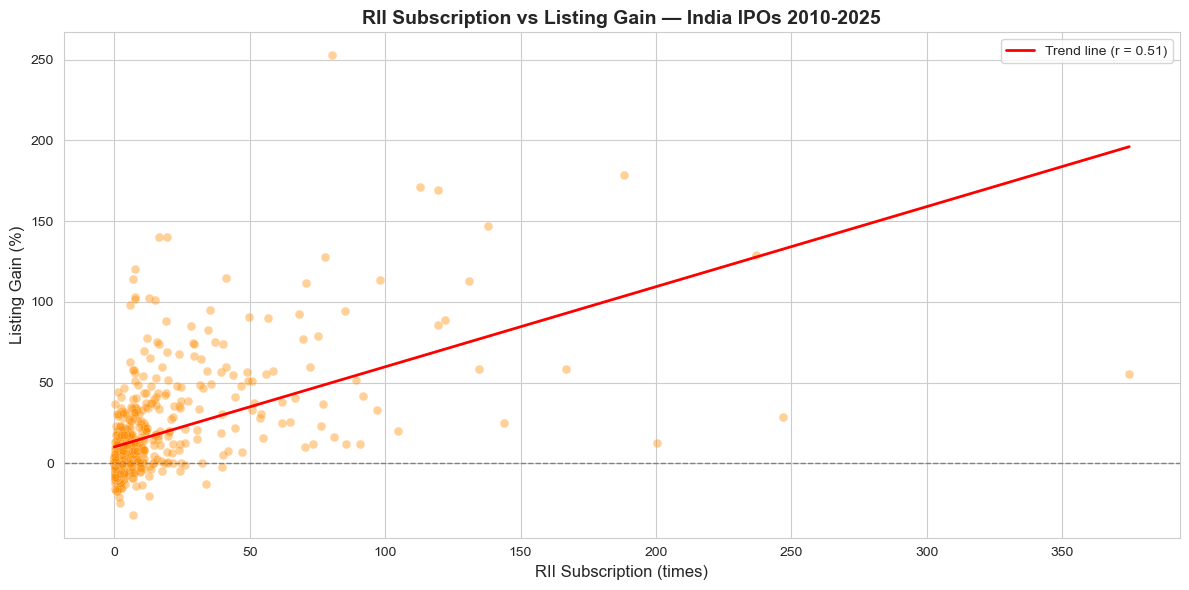

Chart saved.


In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

fig, ax = plt.subplots()
ax.scatter(df['RII'],df['Listing Gain'],alpha=0.4,color='darkorange',edgecolors='white',linewidths=0.3,s=40)

# Trend line
z = np.polyfit(df['RII'], df['Listing Gain'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['RII'].min(), df['RII'].max(), 100)
ax.plot(x_line, p(x_line), color='red',
        linewidth=2, label=f'Trend line (r = {rii_corr:.2f})')

ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)

ax.set_title('RII Subscription vs Listing Gain — India IPOs 2010-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('RII Subscription (times)', fontsize=12)
ax.set_ylabel('Listing Gain (%)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('../charts/03_rii_vs_listing_gain.png', dpi=150)
plt.show()
print("Chart saved.")

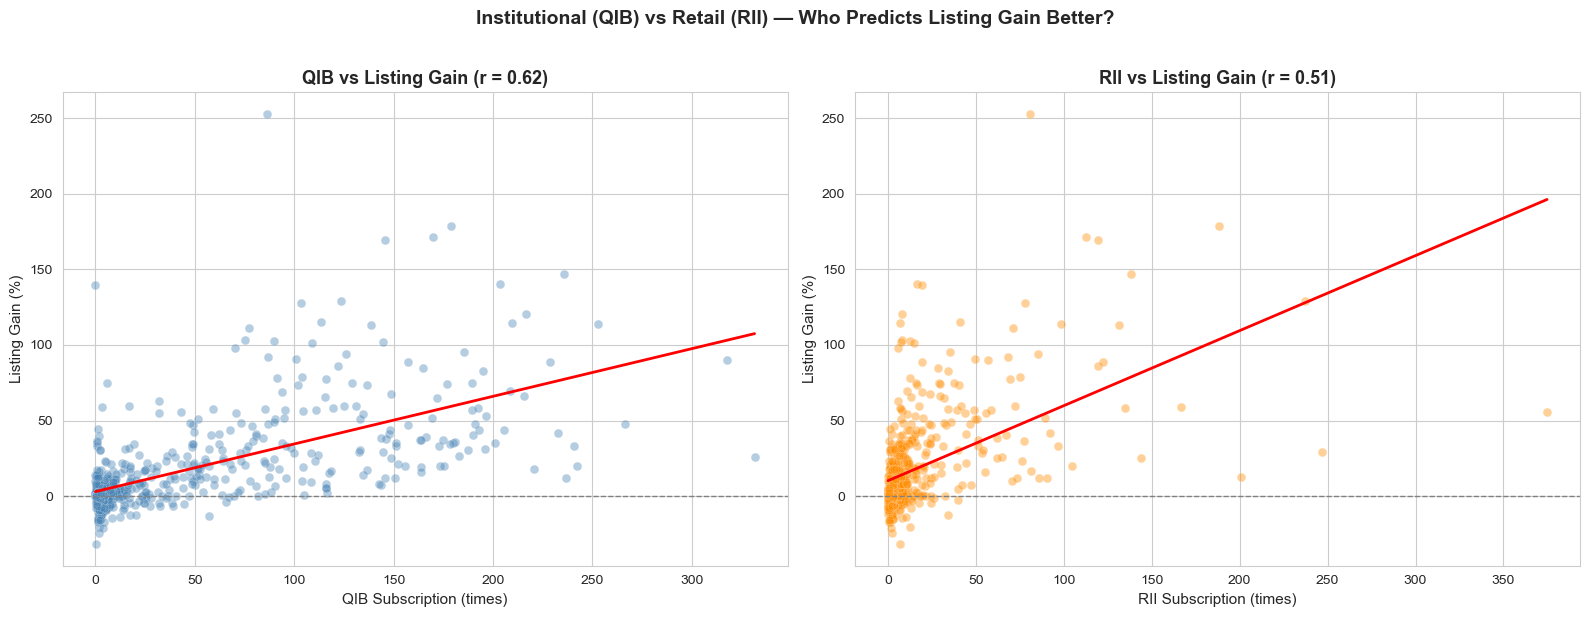

Comparison chart saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# QIB
axes[0].scatter(df['QIB'], df['Listing Gain'],
                alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=40)
z = np.polyfit(df['QIB'], df['Listing Gain'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['QIB'].min(), df['QIB'].max(), 100)
axes[0].plot(x_line, p(x_line), color='red', linewidth=2)
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title(f'QIB vs Listing Gain (r = {qib_corr:.2f})',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('QIB Subscription (times)', fontsize=11)
axes[0].set_ylabel('Listing Gain (%)', fontsize=11)

# RII
axes[1].scatter(df['RII'], df['Listing Gain'],
                alpha=0.4, color='darkorange',
                edgecolors='white', linewidths=0.3, s=40)
z = np.polyfit(df['RII'], df['Listing Gain'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['RII'].min(), df['RII'].max(), 100)
axes[1].plot(x_line, p(x_line), color='red', linewidth=2)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title(f'RII vs Listing Gain (r = {rii_corr:.2f})',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('RII Subscription (times)', fontsize=11)
axes[1].set_ylabel('Listing Gain (%)', fontsize=11)

plt.suptitle('Institutional (QIB) vs Retail (RII) — Who Predicts Listing Gain Better?',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../charts/04_qib_vs_rii_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved.")

In [7]:
# Average listing gain grouped by QIB being above or below median
qib_median = df['QIB'].median()
rii_median = df['RII'].median()

high_qib_gain = df[df['QIB'] > qib_median]['Listing Gain'].mean()
low_qib_gain  = df[df['QIB'] <= qib_median]['Listing Gain'].mean()

high_rii_gain = df[df['RII'] > rii_median]['Listing Gain'].mean()
low_rii_gain  = df[df['RII'] <= rii_median]['Listing Gain'].mean()

print(f"QIB median: {qib_median:.2f}x")
print(f"Avg listing gain — High QIB IPOs: {high_qib_gain:.2f}%")
print(f"Avg listing gain — Low QIB IPOs:  {low_qib_gain:.2f}%")
print(f"\nRII median: {rii_median:.2f}x")
print(f"Avg listing gain — High RII IPOs: {high_rii_gain:.2f}%")
print(f"Avg listing gain — Low RII IPOs:  {low_rii_gain:.2f}%")

QIB median: 14.49x
Avg listing gain — High QIB IPOs: 34.53%
Avg listing gain — Low QIB IPOs:  2.05%

RII median: 5.18x
Avg listing gain — High RII IPOs: 33.81%
Avg listing gain — Low RII IPOs:  2.77%
